Submitted by Marielle Alexa Salvador

In [1]:
!git clone https://github.com/California-Planet-Search/radvel.git

Cloning into 'radvel'...
remote: Enumerating objects: 8693, done.
remote: Counting objects: 100% (393/393), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 8693 (delta 333), reused 313 (delta 313), pack-reused 8300 (from 3)
Receiving objects: 100% (8693/8693), 102.44 MiB | 19.35 MiB/s, done.
Resolving deltas: 100% (5829/5829), done.


In [2]:
!pip install numpy>=1.25
!pip install radvel --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.3/679.3 kB 20.5 MB/s eta 0:00:00


In [3]:
!pip install corner
!pip install nbsphinx
!pip install emcee

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
radvel 1.6.5 requires emcee>=3.0.2, which is not installed.
radvel 1.6.5 requires nbsphinx==0.9.3, which is not installed.
radvel 1.6.5 requires ultranest, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
radvel 1.6.5 requires emcee>=3.0.2, which is not installed.
radvel 1.6.5 requires ultranest, which is not installed.
radvel 1.6.5 requires nbsphinx==0.9.3, but you have nbsphinx 0.9.8 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 383.6 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
radvel 1

In [4]:
%matplotlib inline
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
import corner
import radvel
from radvel.plot import orbit_plots, mcmc_plots
from astropy.timeseries import LombScargle

matplotlib.rcParams['font.size'] = 18

In [5]:
path = os.path.join(radvel.DATADIR,'/content/radvel/example_data/epic203771098.csv')
data = pd.read_csv(path, index_col=0)

print('Path to radvel.DATADIR: {}\n'.format(radvel.DATADIR))
print(data)
print(data.columns.values)

print(f'This is the length of the data:', len(data))

Path to radvel.DATADIR: /usr/radvel_example_data

      errvel            t        vel
0   1.593725  2364.819580   6.959066
1   1.600745  2364.825101   5.017650
2   1.658815  2364.830703  13.811799
3   1.653224  2366.827579   1.151030
4   1.639095  2367.852646   9.389273
5   1.723691  2373.888150  -2.820614
6   1.907690  2374.852412  -0.772991
7   1.709263  2376.863820  -2.222920
8   1.838565  2377.866073   0.146115
9   1.649715  2378.834011   2.739558
10  1.862539  2380.930797   7.571228
11  1.681661  2382.886140   5.137920
12  1.901465  2383.823529   0.368812
13  1.689888  2384.799943  -1.480772
14  1.680251  2384.828991  -2.737295
15  1.718589  2384.839720  -5.682658
16  1.713852  2388.955960  -3.910203
17  1.644495  2395.857258  -5.635432
18  1.760751  2402.898756   3.635211
19  1.649973  2403.771319   3.538690
20  1.460209  2411.755697  -3.754068
21  1.782881  2412.794200  -0.111816
22  1.637531  2420.803019   0.112752
23  1.760237  2421.822804  -2.587854
24  1.656808  2422.742125

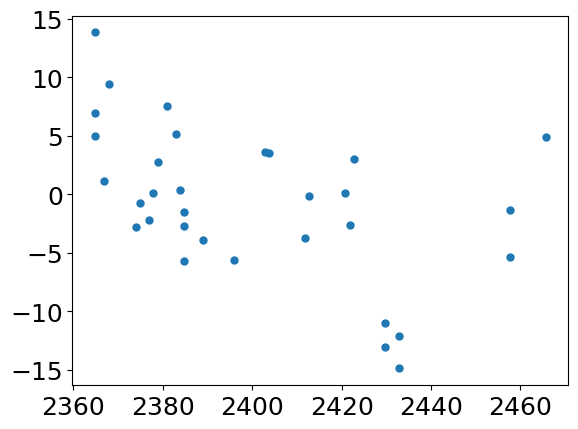

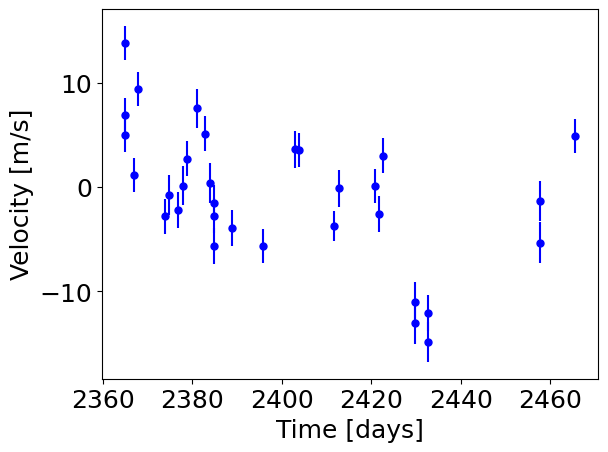

"\nThe plot shows how the star's speed towards or away from us changes over time.\n\nThe pattern looks like a wave, which is often a sign that a planet's gravity is tugging on the star.\nThe size of the wave (how much the speed changes) tells us something about how big or massive the potential planet might be.\nBy looking at how long it takes for the wave pattern to repeat, we can guess how long it takes the planet to orbit the star.\nFrom this plot, it looks like the orbit might take around 40 to 50 days. So, based on the wobbly pattern in the star's speed,\nit seems likely that there's a planet orbiting it. To be sure and to find the exact orbital time, we'd need to do a more detailed analysis.\n\nLooking at the wavy pattern in the plot, it seems like the star's speed goes up and down in a regular cycle.\nThe time it takes to complete one full up-and-down cycle is the orbital period of the planet.\nBy looking at the dips and peaks in the data, we can roughly see that one cycle might 

In [6]:
plt.plot(data.t, data.vel, 'o')
plt.figure()
plt.errorbar(data.t, data.vel, data.errvel, fmt='o', color='b')
plt.xlabel('Time [days]')
plt.ylabel('Velocity [m/s]')
plt.show()

"""
The plot shows how the star's speed towards or away from us changes over time.

The pattern looks like a wave, which is often a sign that a planet's gravity is tugging on the star.
The size of the wave (how much the speed changes) tells us something about how big or massive the potential planet might be.
By looking at how long it takes for the wave pattern to repeat, we can guess how long it takes the planet to orbit the star.
From this plot, it looks like the orbit might take around 40 to 50 days. So, based on the wobbly pattern in the star's speed,
it seems likely that there's a planet orbiting it. To be sure and to find the exact orbital time, we'd need to do a more detailed analysis.

Looking at the wavy pattern in the plot, it seems like the star's speed goes up and down in a regular cycle.
The time it takes to complete one full up-and-down cycle is the orbital period of the planet.
By looking at the dips and peaks in the data, we can roughly see that one cycle might take about 40 to 50 days to complete.
Think of it like watching a pendulum swing back and forth – the time for one full swing is the period. We're doing the same
with the star's speed.

"""

In [7]:
def LombScarg(t,v,e,min_per=0.01,max_per=1000):
    fmin = 1./max_per
    fmax = 1./min_per
    frequency, power = LombScargle(t, v, e).autopower(minimum_frequency=1/1000,maximum_frequency=1.,method='cython')
    per = 1/frequency
    in_window = np.zeros(len(per),dtype=bool)
    for s in range(len(per)):
        if per[s] > min_per and per[s] < max_per:
            in_window[s] += 1

    powmax = max(power[in_window])
    imax = np.argmax(power[in_window])
    fbest = frequency[in_window][imax]
    perbest = 1./fbest

    return per, power, perbest

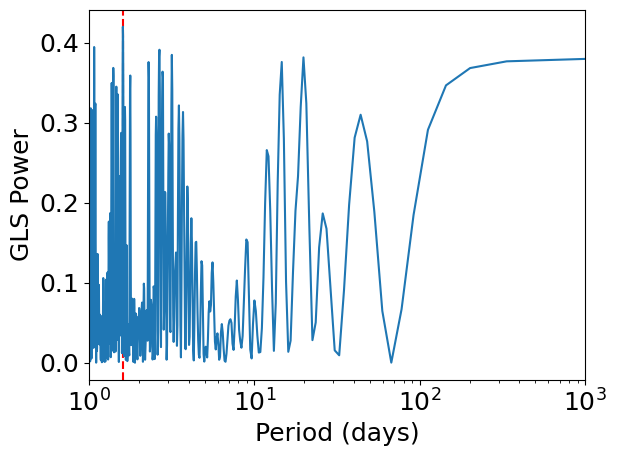

"Changing minPer and maxPer is like adjusting the zoom on a graph of possible orbital times. A wider range lets us see if there are any strong signals (like a planet) orbiting much faster or much slower than we first thought. In our case, zooming out showed us a much stronger signal at a very short period (around 1.6 days) that we didn't see as clearly before."

In [9]:
minPer = 1 # min period to look for 1st planet (in days)
maxPer = 1000 # max period to look for 1st planet (in days)

period, power, period1 = LombScarg(data.t, data.vel,data.errvel,min_per=minPer,max_per=maxPer)
#period1 = 42.36
plt.xlim(minPer,maxPer)
plt.axvline(period1,color='red',linestyle='--')
plt.semilogx(period,power)
plt.xlabel('Period (days)')
plt.ylabel('GLS Power')
plt.show()


"""Changing minPer and maxPer is like adjusting the zoom on a graph of possible orbital times. A wider range lets us see if there are any strong signals (like a planet) orbiting much faster or much slower than we first thought. In our case, zooming out showed us a much stronger signal at a very short period (around 1.6 days) that we didn't see as clearly before."""